# 采购订单交期预测：从数据到未结 PO

这份笔记本做一件事：用已经收货的采购订单，学习「从批准到第一次收货要多少天」，再对两类订单给出预测。

1. **近 4 周才到货的订单**（回测）：模型在训练时完全没见过它们，用来检查预测能不能用。
2. **还没交齐的未结订单**：给出预计交期、预计收货日，以及是否已经晚于预计日。

模型用 [hgboost](https://erdogant.github.io/hgboost/)。它把 XGBoost、LightGBM、CatBoost 放在同一套流程里：先按 60% 训练 / 20% 测试 / 20% 验证切开，再用 Hyperopt 做贝叶斯搜索（默认 500 次），然后只对最好的 10 组参数做 5 折交叉验证，最后把获胜参数在整个开发集上重训。步骤 2 到 9 就是这套自动化。

请先在项目目录安装依赖，再从头到尾运行。三个算法各搜索 500 次，数据量大时会跑几个小时。把配置里的 `MAX_EVAL` 改成 `10` 只能用来检查代码是否连通，那个分数不能当结果。

```text
pip install -r requirements.txt
```

数据库口令写在下面的配置单元格里，只给这台克隆库使用。不要把笔记本提交到公开仓库。


## 先看懂目标，再看代码

原始查询在 `leadtime.txt`。它和收货事务做了内连接，所以一行是一次收货，不是一张订单。训练前会收成 **每个发运行（`line_location_id`）一行**。

- **起算日**：`APPROVED_DATE`。批准日为空时用 `CREATION_DATE`。
- **结束日**：`transaction_type = 'RECEIVE'` 且数量为正的最早 `transaction_date`。
- **预测目标 `lead_time_days`**：结束日减起算日，单位是天。含义是「批准之后，货第一次到要几天」。
- 交期小于等于 0，或大于 `LEAD_TIME_CAP_DAYS`（默认 365 天）的行会删掉，并打印删了多少。
- 收货日期、本次收货数量、累计已收数量 **不能当特征**。它们只有货到了才知道。未结订单上也没有这些值。

未结订单沿用同一个定义：预计收货日 = 起算日 + 预测的天数。


## 配置

下面这些数字控制整个笔记本。改完之后从本单元格往下全部重跑。

- `HISTORY_MONTHS = 24`：只抽取最近 24 个月的收货。设成 `None` 会抽全历史，可能非常慢、非常大。
- `BACKTEST_DAYS = 28`：最新收货日往前 28 天作为回测窗口。
- `TEST_SIZE` 和 `VAL_SIZE` 都是 0.2，剩下约 60% 是训练集。比例是相对 **开发集**（已经拿掉回测之后）来说的。
- `MAX_EVAL = 500`：每个算法尝试 500 组超参数。这就是后面那张「500 个模型的 MAE」图的来源。
- `FORCE_REFRESH`：已有 `data/*.parquet` 时是否重新查库。
- `FORCE_RETRAIN`：已有 `models/*.pkl` 且配置没变时是否重新搜索。


In [1]:
# cell:config
from pathlib import Path
import logging
import pickle
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(message)s", force=True)

# 克隆库连接信息。只放在这个单元格里。
DB_USER = "apps"
DB_PASSWORD = "CLONE"
DB_HOST = "ebsdb-2"
DB_PORT = 1530
DB_SID = "ebs30"
ORACLE_CLIENT_LIB = r"C:\Users\LYWLI\oracle\instantclient_19_32"  # 该库版本需要 thick 模式

HISTORY_MONTHS = 24
LEAD_TIME_CAP_DAYS = 365
BACKTEST_DAYS = 28
TEST_SIZE = 0.2
VAL_SIZE = 0.2
CV_FOLDS = 5
TOP_CV_EVALS = 10
MAX_EVAL = 500
RANDOM_STATE = 42
WITHIN_DAYS = 7
TOP_CATEGORY_LEVELS = 30
FORCE_REFRESH = False
FORCE_RETRAIN = False

ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
MODELS_DIR = ROOT / "models"
OUTPUT_DIR = ROOT / "output"
for folder in (DATA_DIR, MODELS_DIR, OUTPUT_DIR):
    folder.mkdir(parents=True, exist_ok=True)

RECEIPT_CACHE = DATA_DIR / "po_receipts.parquet"
OPEN_CACHE = DATA_DIR / "outstanding_po.parquet"
CLEAN_CACHE = DATA_DIR / "cleaned_leadtime.parquet"

NUMERIC_FEATURES = [
    "po_quantity",
    "unit_price",
    "is_blanket",
    "has_release",
    "approved_month",
    "approved_quarter",
    "approved_dow",
    "requested_lead_days",
    "promised_lead_days",
    "supplier_hist_median_lt",
    "supplier_hist_count",
    "supplier_site_hist_median_lt",
    "supplier_site_hist_count",
    "item_hist_median_lt",
    "item_hist_count",
    "supplier_item_hist_median_lt",
    "supplier_item_hist_count",
]
CATEGORY_FEATURES = ["item_status", "ship_to_location_code", "organization_code"]
HISTORY_SPECS = [
    (["supplier"], "supplier_hist_median_lt", "supplier_hist_count"),
    (["supplier_site_code"], "supplier_site_hist_median_lt", "supplier_site_hist_count"),
    (["item_number"], "item_hist_median_lt", "item_hist_count"),
    (["supplier", "item_number"], "supplier_item_hist_median_lt", "supplier_item_hist_count"),
]
ALGORITHMS = {
    "xgboost": "xgboost_reg",
    "lightgbm": "lightboost_reg",
    "catboost": "catboost_reg",
}

print("项目目录:", ROOT.resolve())
print("MAX_EVAL =", MAX_EVAL, "| 回测天数 =", BACKTEST_DAYS, "| 历史月数 =", HISTORY_MONTHS)


项目目录: C:\Users\LYWLI\Documents\MTRPOPredict
MAX_EVAL = 500 | 回测天数 = 28 | 历史月数 = 24


## 1. 导入并清洗

这一步把克隆库里的收货记录拿下来，收成「一个发运行一行」，并删掉不能学习的行。

查询以 `leadtime.txt` 的表连接为准，只多了三样训练必需的内容：

- `line_location_id`、`line_num`、`organization_code`，用来确定一行是哪条发运、哪个库存组织。
- 收货子查询只保留 `transaction_type = 'RECEIVE'`，数量用收货表自己的 `primary_quantity`。这套克隆库里收货和物料事务对不上，沿用原来的物料事务连接会得到 0 行。
- 24 个月窗口结束在「最后一个还有成批收货的月份」，不结束在 2024 年那几笔零星收货上。这套克隆库的正常收货停在 2022-11。

第一次会写到 `data/po_receipts.parquet`。之后只要 `FORCE_REFRESH = False`，就直接读缓存。

未结订单不在这份查询里，因为原查询内连接了收货。第二段 SQL 用同一套采购表，去掉收货连接，留下「已收数量还小于数量减取消数量」且没有关闭、取消的发运行。


In [2]:
# cell:sql
RECEIPT_SQL = '''
SELECT
    poh.segment1                          po_number,
    poh.approved_date,
    poh.creation_date,
    poh.type_lookup_code,
    pr.release_num,
    pll.need_by_date,
    pll.promised_date,
    pll.quantity - NVL(pll.quantity_cancelled, 0) po_quantity,
    pll.quantity_received                 accumulated_quantity_received,
    rcv.transaction_date,
    rcv.transaction_type,
    rcv.primary_quantity                  transaction_quantity,
    pv.vendor_name                        supplier,
    pvs.vendor_site_code                  supplier_site_code,
    hl.location_code                      ship_to_location_code,
    msi.segment1                          item_number,
    msi.description                       item_desc,
    msi.inventory_item_status_code        item_status,
    pol.unit_price,
    pol.line_num,
    pll.line_location_id,
    mp.organization_code
FROM
    po_headers_all               poh,
    po_lines_all                 pol,
    po_line_locations_all        pll,
    po_releases_all              pr,
    mtl_system_items             msi,
    org_organization_definitions mp,
    po_vendors                   pv,
    po_vendor_sites_all          pvs,
    hr_locations                 hl,
    hr_operating_units           hou,
    (
        SELECT
            rcv.po_line_location_id,
            rcv.transaction_date,
            rcv.transaction_type,
            NVL(rcv.primary_quantity, rcv.quantity) primary_quantity
        FROM rcv_transactions rcv
        WHERE rcv.transaction_type = 'RECEIVE'
          AND rcv.transaction_date BETWEEN ADD_MONTHS((
                SELECT MAX(max_dt) FROM (
                    SELECT MAX(transaction_date) max_dt, COUNT(*) cnt
                    FROM rcv_transactions
                    WHERE transaction_type = 'RECEIVE'
                    GROUP BY TRUNC(transaction_date, 'MM')
                ) WHERE cnt >= 100
              ), -{history_months})
              AND (
                SELECT MAX(max_dt) FROM (
                    SELECT MAX(transaction_date) max_dt, COUNT(*) cnt
                    FROM rcv_transactions
                    WHERE transaction_type = 'RECEIVE'
                    GROUP BY TRUNC(transaction_date, 'MM')
                ) WHERE cnt >= 100
              )
    ) rcv
WHERE poh.type_lookup_code IN ('BLANKET', 'STANDARD')
  AND msi.inventory_item_id = pol.item_id
  AND msi.organization_id = pll.ship_to_organization_id
  AND mp.organization_id = msi.organization_id
  AND poh.po_header_id = pol.po_header_id
  AND pol.po_line_id = pll.po_line_id
  AND pr.po_header_id (+) = poh.po_header_id
  AND NVL(pll.po_release_id, 1) = NVL(pr.po_release_id, 1)
  AND poh.vendor_id = pv.vendor_id
  AND poh.vendor_site_id = pvs.vendor_site_id
  AND pvs.vendor_id = pv.vendor_id
  AND hl.location_id (+) = poh.ship_to_location_id
  AND poh.org_id = hou.organization_id
  AND pll.line_location_id = rcv.po_line_location_id
'''

def _sql_without_history_window(sql):
    start = sql.find("AND rcv.transaction_date BETWEEN")
    end = sql.find(") rcv")
    if start < 0 or end < 0:
        return sql
    return sql[:start] + sql[end:]


RECEIPT_SQL_ALL_HISTORY = _sql_without_history_window(RECEIPT_SQL)

OPEN_SQL = '''
SELECT
    poh.segment1                          po_number,
    poh.approved_date,
    poh.creation_date,
    poh.type_lookup_code,
    pr.release_num,
    pll.need_by_date,
    pll.promised_date,
    pll.quantity - NVL(pll.quantity_cancelled, 0) po_quantity,
    NVL(pll.quantity_received, 0)         accumulated_quantity_received,
    pv.vendor_name                        supplier,
    pvs.vendor_site_code                  supplier_site_code,
    hl.location_code                      ship_to_location_code,
    msi.segment1                          item_number,
    msi.description                       item_desc,
    msi.inventory_item_status_code        item_status,
    pol.unit_price,
    pol.line_num,
    pll.line_location_id,
    mp.organization_code,
    NVL(pll.closed_code, 'OPEN')          line_location_status
FROM
    po_headers_all               poh,
    po_lines_all                 pol,
    po_line_locations_all        pll,
    po_releases_all              pr,
    mtl_system_items             msi,
    org_organization_definitions mp,
    po_vendors                   pv,
    po_vendor_sites_all          pvs,
    hr_locations                 hl,
    hr_operating_units           hou
WHERE poh.type_lookup_code IN ('BLANKET', 'STANDARD')
  AND NVL(poh.cancel_flag, 'N') = 'N'
  AND NVL(pol.cancel_flag, 'N') = 'N'
  AND NVL(pll.cancel_flag, 'N') = 'N'
  AND msi.inventory_item_id = pol.item_id
  AND msi.organization_id = pll.ship_to_organization_id
  AND mp.organization_id = msi.organization_id
  AND poh.po_header_id = pol.po_header_id
  AND pol.po_line_id = pll.po_line_id
  AND pr.po_header_id (+) = poh.po_header_id
  AND NVL(pll.po_release_id, 1) = NVL(pr.po_release_id, 1)
  AND poh.vendor_id = pv.vendor_id
  AND poh.vendor_site_id = pvs.vendor_site_id
  AND pvs.vendor_id = pv.vendor_id
  AND hl.location_id (+) = poh.ship_to_location_id
  AND poh.org_id = hou.organization_id
  AND NVL(pll.quantity_received, 0) < (pll.quantity - NVL(pll.quantity_cancelled, 0))
  AND NVL(pll.closed_code, 'OPEN') NOT IN (
        'CLOSED', 'FINALLY CLOSED', 'CANCELLED', 'CLOSED FOR RECEIVING'
      )
  AND (poh.approved_date IS NOT NULL OR poh.creation_date IS NOT NULL)
'''

source_path = ROOT / "leadtime.txt"
if source_path.exists():
    print("原始查询文件:", source_path.resolve())
else:
    print("当前目录没有 leadtime.txt。SQL 已按该文件的连接方式写在笔记本里。")


def connect_oracle():
    import oracledb
    dsn = oracledb.makedsn(DB_HOST, DB_PORT, sid=DB_SID)
    try:
        return oracledb.connect(user=DB_USER, password=DB_PASSWORD, dsn=dsn)
    except Exception as first_error:
        if not ORACLE_CLIENT_LIB:
            raise RuntimeError(
                "thin 模式没有连上 Oracle。若数据库版本较老，请安装 Instant Client，"
                "把 ORACLE_CLIENT_LIB 设成它的目录后再跑。"
            ) from first_error
        oracledb.init_oracle_client(lib_dir=ORACLE_CLIENT_LIB)
        return oracledb.connect(user=DB_USER, password=DB_PASSWORD, dsn=dsn)


def read_sql(conn, sql):
    cursor = conn.cursor()
    cursor.arraysize = 50000
    cursor.execute(sql)
    columns = [item[0].lower() for item in cursor.description]
    frame = pd.DataFrame(cursor.fetchall(), columns=columns)
    cursor.close()
    return frame


def load_cached(path, sql):
    if path.exists() and not FORCE_REFRESH:
        print(f"读取缓存 {path.name}，不重新查库。")
        frame = pd.read_parquet(path)
        frame.columns = [column.lower() for column in frame.columns]
        return frame
    print(f"正在查询数据库并写入 {path.name} ……")
    conn = connect_oracle()
    try:
        frame = read_sql(conn, sql)
    finally:
        conn.close()
    frame.columns = [column.lower() for column in frame.columns]
    frame.to_parquet(path, index=False)
    print(f"写入 {path} ，{len(frame):,} 行。")
    return frame


原始查询文件: C:\Users\LYWLI\Documents\MTRPOPredict\leadtime.txt


In [3]:
# cell:load
if HISTORY_MONTHS is None:
    receipt_sql = RECEIPT_SQL_ALL_HISTORY
else:
    if not isinstance(HISTORY_MONTHS, int) or HISTORY_MONTHS <= 0:
        raise ValueError("HISTORY_MONTHS 必须是正整数，或 None。")
    receipt_sql = RECEIPT_SQL.format(history_months=int(HISTORY_MONTHS))

receipts_raw = load_cached(RECEIPT_CACHE, receipt_sql)
outstanding_raw = load_cached(OPEN_CACHE, OPEN_SQL)
print("收货事务行数:", f"{len(receipts_raw):,}")
print("未结发运行数:", f"{len(outstanding_raw):,}")
print("收货列:", ", ".join(receipts_raw.columns))


正在查询数据库并写入 po_receipts.parquet ……


写入 C:\Users\LYWLI\Documents\MTRPOPredict\data\po_receipts.parquet ，32,286 行。
读取缓存 outstanding_po.parquet，不重新查库。


收货事务行数: 32,286
未结发运行数: 6,821
收货列: po_number, approved_date, creation_date, type_lookup_code, release_num, need_by_date, promised_date, po_quantity, accumulated_quantity_received, transaction_date, transaction_type, transaction_quantity, supplier, supplier_site_code, ship_to_location_code, item_number, item_desc, item_status, unit_price, line_num, line_location_id, organization_code


### 缺失值、重复收货和交期过滤

同一发运行可能分多批到货。交期取 **第一次正数量收货** 的日期。如果一条发运上没有正数量，就退而使用最早的收货日期，并在过滤阶段按交期规则决定去留。

下面先看原始抽取的缺失比例，再看每条过滤规则删掉了多少行。直方图是清洗之后模型真正要学的交期。长尾很肥时，MAE 会被少数极慢的订单拉高，这是后面读误差时要记住的事。


In [4]:
# cell:clean-fn
DATE_COLUMNS = [
    "approved_date",
    "creation_date",
    "need_by_date",
    "promised_date",
    "transaction_date",
]
NUMBER_COLUMNS = [
    "po_quantity",
    "unit_price",
    "transaction_quantity",
    "accumulated_quantity_received",
    "release_num",
    "line_num",
    "line_location_id",
]


def coerce_columns(frame):
    out = frame.copy()
    out.columns = [column.lower() for column in out.columns]
    for column in DATE_COLUMNS:
        if column in out.columns:
            out[column] = pd.to_datetime(out[column], errors="coerce")
    for column in NUMBER_COLUMNS:
        if column in out.columns:
            out[column] = pd.to_numeric(out[column], errors="coerce")
    return out


def missing_rates(frame):
    rates = frame.isna().mean().sort_values(ascending=False)
    return rates[rates > 0].rename("missing_rate").to_frame()


def plot_missing(frame, title):
    rates = missing_rates(frame).head(20)
    print(title, f"共 {len(frame):,} 行；下面只列出有缺失的列。")
    if rates.empty:
        print("没有缺失值。")
        return
    display(rates.style.format("{:.1%}"))
    fig, ax = plt.subplots(figsize=(8, max(2.8, 0.32 * len(rates))))
    rates.sort_values("missing_rate").plot.barh(ax=ax, legend=False, color="#4c78a8")
    ax.set_xlabel("缺失比例")
    ax.set_title(title)
    fig.tight_layout()
    plt.show()


def aggregate_first_receipt(raw):
    df = coerce_columns(raw)
    required = {"line_location_id", "transaction_date", "transaction_quantity"}
    missing = required - set(df.columns)
    if missing:
        raise KeyError(f"收货结果缺少列: {sorted(missing)}")
    before = len(df)
    df = df.dropna(subset=["line_location_id", "transaction_date"]).copy()
    dropped_keys = before - len(df)
    df["_positive"] = df["transaction_quantity"].fillna(0) > 0
    df = df.sort_values(
        ["line_location_id", "_positive", "transaction_date"],
        ascending=[True, False, True],
        kind="mergesort",
    )
    first = df.groupby("line_location_id", as_index=False).head(1).drop(columns="_positive")
    first = first.reset_index(drop=True)
    print(f"收货事务 {before:,} 行，缺发运或收货日的删掉 {dropped_keys:,} 行，收成 {len(first):,} 个发运行。")
    return first


def clean_completed_lines(first, cap_days):
    work = first.copy()
    work["start_date"] = work["approved_date"].fillna(work["creation_date"])
    work["lead_time_days"] = (
        work["transaction_date"].dt.normalize() - work["start_date"].dt.normalize()
    ).dt.days
    rows = []

    def apply_rule(mask, rule):
        nonlocal work
        before = len(work)
        work = work.loc[mask].copy()
        rows.append({"rule": rule, "removed": before - len(work), "remaining": len(work)})

    apply_rule(work["start_date"].notna(), "缺少批准日和创建日")
    apply_rule(work["lead_time_days"].notna(), "交期算不出来")
    apply_rule(work["lead_time_days"] > 0, "交期小于等于 0 天")
    apply_rule(work["lead_time_days"] <= cap_days, f"交期大于 {cap_days} 天")
    apply_rule(work["po_quantity"].fillna(0) > 0, "订单数量小于等于 0")
    apply_rule(work["supplier"].notna() & work["item_number"].notna(), "缺少供应商或物料")
    log = pd.DataFrame(rows)
    return work.reset_index(drop=True), log


清洗前：原始收货抽取的缺失比例 共 32,286 行；下面只列出有缺失的列。


,missing_rate
release_num,68.2%
need_by_date,0.1%


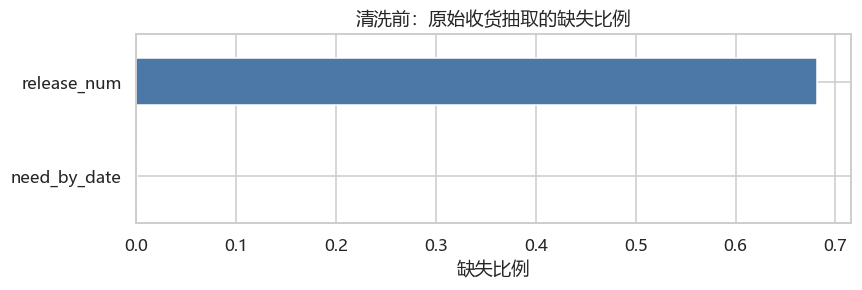

收货事务 32,286 行，缺发运或收货日的删掉 0 行，收成 28,921 个发运行。


,rule,removed,remaining
0,缺少批准日和创建日,0,28921
1,交期算不出来,0,28921
2,交期小于等于 0 天,4940,23981
3,交期大于 365 天,2408,21573
4,订单数量小于等于 0,0,21573
5,缺少供应商或物料,0,21573


清洗后 21,573 行。交期中位数 125 天，平均值 137.7 天，90 分位 275 天。


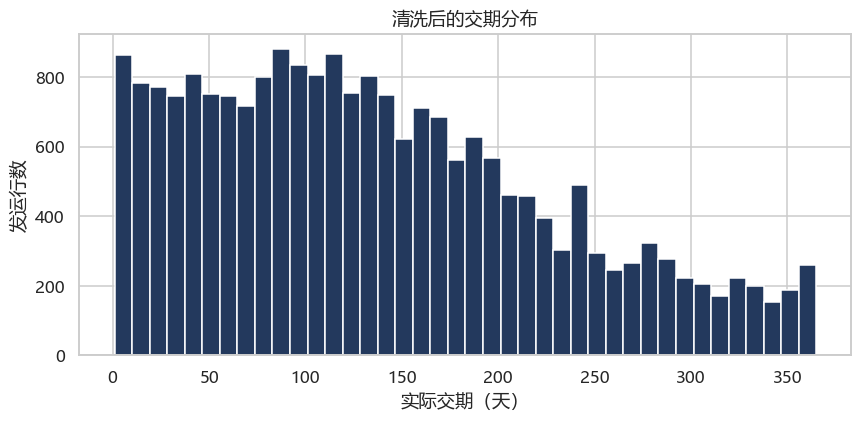

In [5]:
# cell:clean-run
plot_missing(receipts_raw, "清洗前：原始收货抽取的缺失比例")
first_receipt = aggregate_first_receipt(receipts_raw)
cleaned, clean_log = clean_completed_lines(first_receipt, LEAD_TIME_CAP_DAYS)
display(clean_log)
print(
    f"清洗后 {len(cleaned):,} 行。交期中位数 {cleaned['lead_time_days'].median():.0f} 天，"
    f"平均值 {cleaned['lead_time_days'].mean():.1f} 天，"
    f"90 分位 {cleaned['lead_time_days'].quantile(0.9):.0f} 天。"
)
cleaned.to_parquet(CLEAN_CACHE, index=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(cleaned["lead_time_days"], bins=40, color="#23395d", edgecolor="white")
ax.set_xlabel("实际交期（天）")
ax.set_ylabel("发运行数")
ax.set_title("清洗后的交期分布")
fig.tight_layout()
plt.show()


**怎么读这两张图**

缺失比例条形图里，条越长，这一列越不完整。批准日、需求日、承诺日有缺失是常见的：批准日缺失时改用创建日；需求日或承诺日缺失时，对应的「要求交期」「承诺交期」特征留空，稍后用开发集的中位数补上。供应商或物料整列缺失则这条订单无法学习，过滤表里会把它删掉。

交期直方图的横轴是天数，纵轴是发运行数。高峰所在的位置就是最常见的到货速度。如果右边拖着一条长尾巴，说明有少量订单特别慢。模型优化的是 MAE，也就是平均差几天，长尾巴会把平均误差抬高。上限 `LEAD_TIME_CAP_DAYS` 就是用来去掉明显不合理的极端值；若你们的正常交期经常超过一年，把这个上限调大，并重跑清洗之后的所有单元格。


## 订单下达时就能知道的特征

树模型只能使用下单当时已经知道的信息。数量、单价、是否一揽子协议、有没有发放、收货地点、库存组织、物料状态、批准日落在哪个月、要求交期、承诺交期，都属于这类信息。

供应商、供应商地点、物料编号的取值太多。如果做成独热编码，列数会膨胀到 hgboost 很难搜完。这里改成 **批准日之前已经发生过的收货** 的中位数交期，以及当时已经有过多少次收货：

- 该供应商以前的中位交期和次数
- 该供应商地点以前的中位交期和次数
- 该物料以前的中位交期和次数
- 该供应商加该物料以前的中位交期和次数

「以前」按收货日严格早于本行批准日计算。本行自己的到货、以及批准之后才到的货，都不会进这四个数。没有任何历史时，中位数先回退到物料、再回退到供应商，最后回退到开发集的全局中位数；次数填 0。

供应商加物料的历史中位数，同时也是对照基线。提升树只有在验证和回测上都比这个基线更接近真实交期，才说明搜索是有用的。


In [6]:
# cell:feature-fn
KEY_COLUMNS = ["supplier", "supplier_site_code", "item_number", "item_status", "ship_to_location_code", "organization_code"]


def fill_text_keys(frame):
    out = frame.copy()
    for column in KEY_COLUMNS:
        if column in out.columns:
            out[column] = out[column].astype("string").fillna("MISSING").astype(str)
    return out


def add_order_time_features(frame):
    out = fill_text_keys(frame)
    if "start_date" not in out.columns:
        out["start_date"] = out["approved_date"].fillna(out["creation_date"])
    out["start_date"] = pd.to_datetime(out["start_date"], errors="coerce")
    for column in ("need_by_date", "promised_date"):
        if column not in out.columns:
            out[column] = pd.NaT
        out[column] = pd.to_datetime(out[column], errors="coerce")
    out["is_blanket"] = out["type_lookup_code"].astype(str).str.upper().eq("BLANKET").astype(np.float32)
    out["has_release"] = out["release_num"].notna().astype(np.float32)
    out["approved_month"] = out["start_date"].dt.month.astype("float")
    out["approved_quarter"] = out["start_date"].dt.quarter.astype("float")
    out["approved_dow"] = out["start_date"].dt.dayofweek.astype("float")
    out["requested_lead_days"] = (out["need_by_date"].dt.normalize() - out["start_date"].dt.normalize()).dt.days.astype("float")
    out["promised_lead_days"] = (out["promised_date"].dt.normalize() - out["start_date"].dt.normalize()).dt.days.astype("float")
    out["po_quantity"] = pd.to_numeric(out["po_quantity"], errors="coerce")
    out["unit_price"] = pd.to_numeric(out["unit_price"], errors="coerce")
    return out


def attach_prior_stats(history, query, keys, value_col, hist_time, query_time):
    # Median and count of value_col using history rows strictly before each query time.
    keys = list(keys)
    empty_median = np.full(len(query), np.nan)
    empty_count = np.zeros(len(query))
    if len(query) == 0:
        return empty_median, empty_count
    hist = history.dropna(subset=keys + [hist_time, value_col]).copy()
    if hist.empty:
        return empty_median, empty_count
    hist = hist.sort_values(keys + [hist_time, "line_location_id"], kind="mergesort")
    grouped = hist.groupby(keys, sort=False)[value_col]
    hist["_med"] = grouped.transform(lambda series: series.expanding(min_periods=1).median())
    hist["_cnt"] = grouped.cumcount() + 1
    hist = hist.drop_duplicates(subset=keys + [hist_time], keep="last")
    right = hist[keys + [hist_time, "_med", "_cnt"]].copy()
    for key in keys:
        right[key] = right[key].astype(str)
    right = right.sort_values(hist_time, kind="mergesort")

    left = query.copy()
    left["_row"] = np.arange(len(left))
    for key in keys:
        left[key] = left[key].astype(str)
    if left[query_time].isna().any():
        raise ValueError(f"{query_time} 有空值，无法按时间对齐历史交期。")
    left = left.sort_values(query_time, kind="mergesort")
    merged = pd.merge_asof(
        left,
        right,
        left_on=query_time,
        right_on=hist_time,
        by=keys,
        direction="backward",
        allow_exact_matches=False,
    ).sort_values("_row")
    if not np.array_equal(merged["_row"].to_numpy(), np.arange(len(query))):
        raise RuntimeError("历史特征没有按原行序对齐。")
    return merged["_med"].to_numpy(), merged["_cnt"].fillna(0).to_numpy()


def add_history_features(frame, history, query_time):
    out = frame.copy()
    for keys, median_name, count_name in HISTORY_SPECS:
        median, count = attach_prior_stats(
            history, out, keys, "lead_time_days", "transaction_date", query_time
        )
        out[median_name] = median
        out[count_name] = count
    return out


def cascade_history(frame, global_median):
    out = frame.copy()
    out["supplier_hist_median_lt"] = out["supplier_hist_median_lt"].fillna(global_median)
    out["supplier_site_hist_median_lt"] = out["supplier_site_hist_median_lt"].fillna(out["supplier_hist_median_lt"])
    out["item_hist_median_lt"] = out["item_hist_median_lt"].fillna(out["supplier_hist_median_lt"])
    out["supplier_item_hist_median_lt"] = (
        out["supplier_item_hist_median_lt"].fillna(out["item_hist_median_lt"]).fillna(out["supplier_hist_median_lt"])
    )
    for column in (
        "supplier_hist_count",
        "supplier_site_hist_count",
        "item_hist_count",
        "supplier_item_hist_count",
    ):
        out[column] = out[column].fillna(0)
    return out


def fit_category_levels(frame, columns, top_n):
    levels = {}
    for column in columns:
        values = frame[column].fillna("MISSING").astype(str)
        counts = values.value_counts().rename_axis("level").reset_index(name="n")
        counts = counts.sort_values(["n", "level"], ascending=[False, True])
        levels[column] = counts["level"].head(top_n).tolist()
    return levels


def encode_categories(frame, levels):
    pieces = []
    for column, keep in levels.items():
        values = frame[column].fillna("MISSING").astype(str).to_numpy()
        bucket = np.where(np.isin(values, keep), values, "__OTHER__")
        data = {f"{column}={level}": (bucket == level).astype(np.float32) for level in keep}
        data[f"{column}=__OTHER__"] = (bucket == "__OTHER__").astype(np.float32)
        pieces.append(pd.DataFrame(data, index=frame.index))
    if not pieces:
        return pd.DataFrame(index=frame.index)
    return pd.concat(pieces, axis=1)


def build_matrix(frame, spec):
    numeric = frame.loc[:, spec["numeric_features"]].apply(pd.to_numeric, errors="coerce")
    for column, median in spec["impute_medians"].items():
        if column in numeric.columns:
            numeric[column] = numeric[column].fillna(median)
    numeric = numeric.fillna(spec["global_median"])
    dummies = encode_categories(frame, spec["category_levels"])
    matrix = pd.concat([numeric.reset_index(drop=True), dummies.reset_index(drop=True)], axis=1)
    matrix = matrix.reindex(columns=spec["feature_columns"], fill_value=0.0)
    matrix = matrix.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan).fillna(0.0)
    matrix = matrix.astype(np.float32)
    matrix.columns = matrix.columns.astype(str)
    return matrix


## 2. 怎么切数据

随机把行打散，不能直接当成「未来的订单准不准」。一张更晚的收货若被分进训练集，模型就偷看了未来。所以 **先按时间把近 4 周拿开**，hgboost 的随机划分只发生在更早的开发集内部。

- **开发集**：收货日早于切点。搜索、交叉验证、重训都只用它。
- **回测集**：收货日落在切点之后的 28 天里，而且批准日早于切点。这些订单在切点当天已经存在，货是后来才到的。
- **窗口内新开并已收货**：批准和收货都发生在这 28 天里。它们不是「当时已经在途」的订单，不放进训练，也不放进这次回测。

开发集内部再切三份，比例按全部开发集计算：

- **训练集，约 60%**：每组超参数都在这里拟合。
- **测试集，约 20%**：500 次试验共用这一份固定切片。大家考同一张卷，比较才公平。
- **验证集，约 20%**：搜索和 5 折都结束之后才用一次。用它的分数再回头改参数，这张卷就作废了。

hgboost 的实现是：先抽走 20% 当验证集，再把剩下的 80% 按 75% / 25% 分成训练和测试。25% × 80% = 20%，所以测试集仍然是开发集的 20%。实际行数会因取整差几行，图上的数字以程序算出来的为准。


In [7]:
# cell:split-fn
from matplotlib.patches import FancyBboxPatch


def development_indices(n_rows, test_size, val_size, random_state):
    # Reproduce hgboost's validation split, then the adjusted test split.
    index = np.arange(n_rows)
    rest, validation = train_test_split(index, test_size=val_size, random_state=random_state, shuffle=True)
    adjusted_test = float(np.round((test_size * n_rows) / (n_rows - (val_size * n_rows)), 2))
    train, test = train_test_split(rest, test_size=adjusted_test, random_state=random_state, shuffle=True)
    return np.sort(train), np.sort(test), np.sort(validation), adjusted_test


def draw_split_diagram(counts):
    fig, ax = plt.subplots(figsize=(12.5, 9))
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.axis("off")
    ax.set_title("数据如何分成训练集、测试集、验证集和 4 周回测", fontsize=14, pad=8)

    def box(x, y, w, h, text, color):
        patch = FancyBboxPatch(
            (x, y), w, h,
            boxstyle="round,pad=0.3,rounding_size=0.8",
            facecolor=color, edgecolor="#1f3b57", linewidth=1.1,
        )
        ax.add_patch(patch)
        ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=8.5, color="#102033")

    box(28, 88, 44, 9, f"清洗后的已收货发运行\n{counts['cleaned']:,} 行", "#d6e2f0")
    box(2, 68, 30, 14, f"开发集\n收货早于 {counts['cutoff']}\n{counts['development']:,} 行", "#d9ead3")
    box(35, 68, 30, 14, f"4 周回测，训练时不看\n批准早于切点、窗口内才到货\n{counts['backtest']:,} 行", "#ffe6c2")
    box(68, 68, 30, 14, f"窗口内新开并已收货\n不训练，也不计入本次回测\n{counts['excluded']:,} 行", "#f4cccc")
    box(2, 46, 20, 14, f"训练集 约 60%\n{counts['train']:,} 行\n拟合每一组参数", "#e7f5e1")
    box(24, 46, 20, 14, f"测试集 约 20%\n{counts['test']:,} 行\n500 次试验的固定考卷", "#fff4cc")
    box(46, 46, 22, 14, f"验证集 约 20%\n{counts['validation']:,} 行\n选定后再评一次", "#f8d7da")
    box(2, 24, 66, 14, "内层循环：贝叶斯搜索。训练集拟合，测试集打 MAE。\n外层循环：只取测试集最好的 10 组，做 5 折交叉验证，丢掉不稳定的获胜者。", "#eef2f7")
    box(2, 6, 66, 12, "按 5 折平均 MAE 选出算法，再在整个开发集上重训。\n回测和未结 PO 都用这个模型。回测不参与重训。", "#e3f2e6")
    arrow = dict(arrowstyle="->", color="#1f3b57", lw=1.1)
    ax.annotate("", xy=(17, 82), xytext=(42, 88), arrowprops=arrow)
    ax.annotate("", xy=(50, 82), xytext=(52, 88), arrowprops=arrow)
    ax.annotate("", xy=(80, 82), xytext=(62, 88), arrowprops=arrow)
    ax.annotate("", xy=(12, 60), xytext=(16, 68), arrowprops=arrow)
    ax.annotate("", xy=(34, 60), xytext=(20, 68), arrowprops=arrow)
    ax.annotate("", xy=(56, 60), xytext=(24, 68), arrowprops=arrow)
    ax.annotate("", xy=(34, 38), xytext=(34, 46), arrowprops=arrow)
    ax.annotate("", xy=(34, 18), xytext=(34, 24), arrowprops=arrow)
    fig.tight_layout()
    plt.show()


最新收货日 2022-11-26 ，回测切点 2022-10-29 （收货日 >= 切点的 28 天窗口）。
hgboost 在抽走验证集之后，测试集占剩余开发集的比例是 0.25，对应全部开发集的约 20%。
开发集里没有供应商-物料历史的行占 70.5%。这些行会退回供应商或全局中位数，通常更难测准。


,cleaned,cutoff,development,backtest,excluded,train,test,validation
0,21573,2022-10-29,20777,702,94,12465,4156,4156


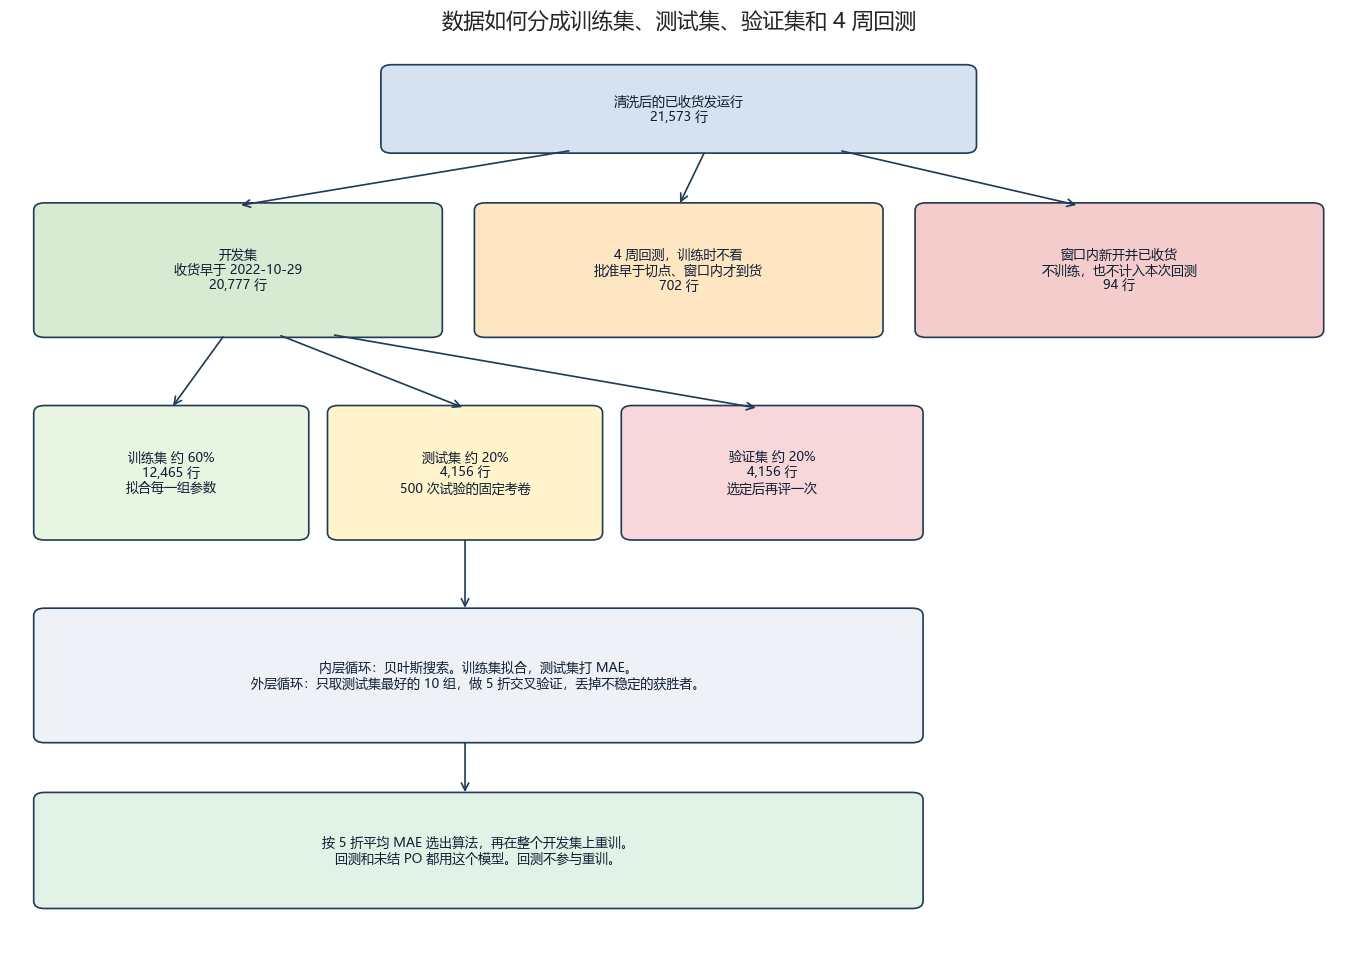

特征矩阵: (20777, 55) ，目标中位数: 125.0


In [8]:
# cell:split-run
featured = add_order_time_features(cleaned)
featured = add_history_features(featured, featured, query_time="start_date")

asof_day = featured["transaction_date"].max().normalize()
cutoff = asof_day - pd.Timedelta(days=BACKTEST_DAYS)
received_in_window = featured["transaction_date"] >= cutoff
approved_before_cutoff = featured["start_date"] < cutoff
backtest_mask = received_in_window & approved_before_cutoff
excluded_mask = received_in_window & ~approved_before_cutoff
development_mask = ~received_in_window

development = featured.loc[development_mask].sort_values("line_location_id", kind="mergesort").reset_index(drop=True)
backtest = featured.loc[backtest_mask].sort_values("line_location_id", kind="mergesort").reset_index(drop=True)
excluded = featured.loc[excluded_mask]
if len(development) < 50:
    raise RuntimeError(f"开发集只有 {len(development)} 行，至少需要 50 行才能做 20/20 划分和 5 折。")

global_median = float(development["lead_time_days"].median())
development = cascade_history(development, global_median)
backtest = cascade_history(backtest, global_median)

category_levels = fit_category_levels(development, CATEGORY_FEATURES, TOP_CATEGORY_LEVELS)
impute_medians = {}
for column in NUMERIC_FEATURES:
    median = float(pd.to_numeric(development[column], errors="coerce").median())
    impute_medians[column] = global_median if np.isnan(median) else median
dummy_columns = list(encode_categories(development, category_levels).columns)
spec = {
    "numeric_features": list(NUMERIC_FEATURES),
    "category_levels": category_levels,
    "impute_medians": impute_medians,
    "global_median": global_median,
    "feature_columns": list(NUMERIC_FEATURES) + dummy_columns,
    "cutoff": cutoff.isoformat(),
    "lead_time_cap_days": LEAD_TIME_CAP_DAYS,
}
with open(MODELS_DIR / "feature_spec.pkl", "wb") as handle:
    pickle.dump(spec, handle)

X_dev = build_matrix(development, spec)
y_dev = development["lead_time_days"].to_numpy(dtype=float)
train_idx, test_idx, val_idx, adjusted_test = development_indices(len(X_dev), TEST_SIZE, VAL_SIZE, RANDOM_STATE)
no_history = float((development["supplier_item_hist_count"] == 0).mean())

split_counts = {
    "cleaned": len(featured),
    "cutoff": cutoff.date().isoformat(),
    "development": len(development),
    "backtest": len(backtest),
    "excluded": len(excluded),
    "train": len(train_idx),
    "test": len(test_idx),
    "validation": len(val_idx),
}
print(f"最新收货日 {asof_day.date()} ，回测切点 {cutoff.date()} （收货日 >= 切点的 {BACKTEST_DAYS} 天窗口）。")
print(f"hgboost 在抽走验证集之后，测试集占剩余开发集的比例是 {adjusted_test:.2f}，对应全部开发集的约 20%。")
print(f"开发集里没有供应商-物料历史的行占 {no_history:.1%}。这些行会退回供应商或全局中位数，通常更难测准。")
display(pd.DataFrame([split_counts]))
draw_split_diagram(split_counts)
if X_dev.isna().any().any():
    raise RuntimeError("特征矩阵里还有缺失值。")
print("特征矩阵:", X_dev.shape, "，目标中位数:", np.median(y_dev))


**怎么读划分图**

从上往下看。最上面是清洗后的全部已收货发运行。第一刀是时间：绿色开发集可以学习，橙色回测要留到最后，红色是窗口里才下单并且已经到货的行，两头都不进。

绿色盒子再切成训练、测试、验证。训练决定树长什么样，测试给 500 组参数排名，验证只负责在排名结束之后报告一次 MAE。最下面两格是流程而不是新的数据：先搜索、再 5 折、再在整个绿色开发集上重训。橙色回测不在这次重训里。

图下面打印的「没有供应商-物料历史」的比例如果很高，说明很多组合是第一次买。模型这时主要靠供应商整体水平和物料整体水平，误差通常会更大。


## 3. 用什么指标

业务问题是「预计到货日会差几天」。主指标用 **MAE（平均绝对误差）**：把每张订单的绝对误差加起来再平均，单位就是天。hgboost 的 `eval_metric='mae'`，500 次试验和 5 折都按它排序。MAE 越低越好。

同时报告四个辅助数，它们不参与搜索：

- **RMSE**：先平方再开方，差得很远的订单会被罚得更重。
- **R²**：模型比「永远猜平均值」多解释了多少波动。越接近 1 越好，0 表示没有比猜平均值更好。
- **MedianAE**：中位数绝对误差。比 MAE 更不受个别极慢订单影响。
- **7 天内占比**：绝对误差不超过 7 天的订单比例。采购更容易拿这个数做判断。

三个算法之间，用 **5 折平均 MAE** 决定名次，而不是用某一次测试集上的最低分。验证集 MAE 是无偏核对。测试集 MAE 明显好于验证集 MAE 时，说明这组参数把那张固定考卷背熟了。


In [9]:
# cell:metrics
def regression_metrics(y_true, y_pred):
    actual = np.asarray(y_true, dtype=float).reshape(-1)
    pred = np.asarray(y_pred, dtype=float).reshape(-1)
    error = np.abs(actual - pred)
    return {
        "MAE": float(mean_absolute_error(actual, pred)),
        "RMSE": float(np.sqrt(mean_squared_error(actual, pred))),
        "R2": float(r2_score(actual, pred)),
        "MedianAE": float(np.median(error)),
        "Within_7_days": float(np.mean(error <= WITHIN_DAYS)),
    }


def metrics_frame(named_predictions, y_true):
    rows = []
    for name, pred in named_predictions.items():
        row = {"model": name}
        row.update(regression_metrics(y_true, pred))
        rows.append(row)
    return pd.DataFrame(rows).set_index("model")


## 4. 嵌套交叉验证：三个算法各搜一遍

每个算法单独建一个 `hgboost` 对象，避免上一个算法改过的切分比例带进下一个。

- **内层**：Hyperopt 的 TPE 贝叶斯搜索。它会参考已经试过的参数和 MAE，决定下一组参数往哪边走，而不是把学习率、深度、树棵数的所有组合都网格化。默认预算是 500 次。每一次都在同一份训练集上拟合，在同一份测试集上计算 MAE。
- **外层**：500 次里测试集 MAE 最好的 10 组，各自做 5 折。折与折之间会重新抽训练和测试，用来看这组参数是不是只在原来那一刀上好看。平均 MAE 最低的那一组留下。
- 三个算法的随机种子都是 42，因此验证集、测试集是同一批行。

搜索进行中，屏幕可能安静较长时间，这是正常的。500 次结束才会打印最佳 MAE，随后出现 5 折的进度条。

XGBoost 搜索的主要是 `learning_rate`、`max_depth`、`min_child_weight`、`gamma`、`reg_lambda`、`subsample`、`n_estimators`。LightGBM 搜索学习率、深度、叶子最小权重、行采样和树棵数。CatBoost 搜索学习率、深度、`colsample_bylevel` 和树棵数。树在验证误差不再下降时会提前停止，避免把训练集背下来。


In [10]:
# cell:train
try:
    from hgboost import hgboost
except ImportError as exc:
    raise ImportError("缺少 hgboost。请先运行 pip install -r requirements.txt") from exc

for logger_name in ("hgboost", "hgboost.hgboost"):
    logging.getLogger(logger_name).setLevel(logging.INFO)


def training_stamp(feature_spec, n_rows):
    return {
        "max_eval": MAX_EVAL,
        "random_state": RANDOM_STATE,
        "test_size": TEST_SIZE,
        "val_size": VAL_SIZE,
        "cv": CV_FOLDS,
        "top_cv_evals": TOP_CV_EVALS,
        "n_rows": int(n_rows),
        "features": list(feature_spec["feature_columns"]),
    }


def summary_flag(summary, column):
    if column not in summary.columns:
        raise KeyError(f"hgboost 结果里没有列 {column}")
    return summary.loc[summary[column].fillna(False) == True]


def show_top10(name, summary):
    table = summary.copy()
    if "default_params" in table.columns:
        table = table.loc[table["default_params"].fillna(False) != True]
    ranked = table.dropna(subset=["loss_mean"]).sort_values(["loss_mean", "loss_std"])
    columns = ["loss", "loss_mean", "loss_std", "best", "best_cv", "learning_rate", "max_depth",
               "min_child_weight", "n_estimators", "subsample", "gamma", "reg_lambda", "colsample_bylevel"]
    columns = [column for column in columns if column in ranked.columns]
    print(f"{name}：5 折平均 MAE 最好的前 {min(10, len(ranked))} 组参数")
    display(ranked[columns].head(10))


def new_hgboost():
    return hgboost(
        max_eval=MAX_EVAL,
        cv=CV_FOLDS,
        test_size=TEST_SIZE,
        val_size=VAL_SIZE,
        top_cv_evals=TOP_CV_EVALS,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        gpu=False,
        verbose="info",
    )


stamp = training_stamp(spec, len(X_dev))
stamp_path = MODELS_DIR / "training_stamp.pkl"
stamp_matches = False
if stamp_path.exists() and not FORCE_RETRAIN:
    try:
        with open(stamp_path, "rb") as handle:
            stamp_matches = pickle.load(handle) == stamp
    except Exception:
        stamp_matches = False

class _QuietStdout:
    # XGBoost prints every tree to stdout. Keep the notebook readable and store that text in a log.
    def __enter__(self):
        import sys
        self._stdout = sys.stdout
        self._handle = open(MODELS_DIR / "search_stdout.log", "a", encoding="utf-8")
        sys.stdout = self._handle
        return self

    def __exit__(self, *args):
        import sys
        sys.stdout = self._stdout
        self._handle.close()

trained = {}
for name, method_name in ALGORITHMS.items():
    path = MODELS_DIR / f"{name}.pkl"
    model = new_hgboost()
    loaded = False
    if path.exists() and stamp_matches and not FORCE_RETRAIN:
        print(f"读取已训练的 {name}。配置或开发集变了才会重训。")
        try:
            model.load(str(path))
            loaded = getattr(model, "model", None) is not None and model.results is not None
        except Exception as exc:
            print(f"读取 {name} 失败，改为重新训练：{exc}")
            model = new_hgboost()
    if not loaded:
        print(f"开始训练 {name} ，最多 {MAX_EVAL} 次搜索。树的逐轮输出写在 models/search_stdout.log。")
        with _QuietStdout():
            getattr(model, method_name)(X_dev.copy(), y_dev.copy(), eval_metric="mae")
        model.save(str(path), overwrite=True)
    if hasattr(model, "y_val"):
        if not np.allclose(np.sort(model.y_val), np.sort(y_dev[val_idx])):
            raise RuntimeError(f"{name} 的验证集和笔记本复原的切分不一致。")
    trained[name] = model
    show_top10(name, model.results["summary"])

if not stamp_matches or FORCE_RETRAIN:
    with open(stamp_path, "wb") as handle:
        pickle.dump(stamp, handle)
print("三个算法都已就绪。")


2026-10-03 18:48:24,960 Start hgboost regression.


2026-10-03 18:48:24,962 Collecting xgb_reg parameters.


2026-10-03 18:48:24,970 method: xgb_reg


2026-10-03 18:48:24,971 eval_metric: mae


2026-10-03 18:48:24,973 larger_is_better: False


...

2026-10-04 08:12:36,075 TPE using 444/444 trials with best loss 25.032697


2026-10-04 08:12:39,401 build_posterior_wrapper took 0.005431 seconds


2026-10-04 08:12:39,406 TPE using 445/445 trials with best loss 25.032697


2026-10-04 08:12:40,803 job exception: bad allocation


CatBoostError: bad allocation

**怎么读每个算法的前 10 行**

`loss` 是这组参数在固定测试集上的 MAE。`loss_mean` 是 5 折的平均 MAE，`loss_std` 是这 5 折的波动。`best` 为真，表示它是 500 次里测试集最好的那次。`best_cv` 为真，表示它在前 10 名里 5 折平均最好，这才是该算法留下的参数。

如果某一行 `loss` 很低，但 `loss_mean` 高或者 `loss_std` 很大，它就是「这张卷考得好、换一折就不行」的参数，不会被选中。这就是外层循环在防过训练。


## 5. 选出能泛化的模型

名次只看各算法 `best_cv` 那一行的 5 折平均 MAE，平均相同再看标准差，标准差更小的更稳。验证集不参与这个名次，避免用最终考卷来选题。

表里还有两列对照：

- `search_test_mae`：贝叶斯搜索在固定测试集上的最好 MAE。
- `validation_mae_before_refit`：hgboost 在「用整个开发集重训」之前，对验证集算出的 MAE。这是验证集上的无偏 MAE。
- `default_validation_mae`：同一份验证集上，不调参的默认模型的 MAE。它高于调参后的验证 MAE，才说明这 500 次搜索有收获。


In [ ]:
# cell:rank
ranking_rows = []
for name, model in trained.items():
    summary = model.results["summary"]
    best_search = summary_flag(summary, "best").iloc[0]
    best_cv = summary_flag(summary, "best_cv").iloc[0]
    default_rows = summary_flag(summary, "default_params") if "default_params" in summary.columns else pd.DataFrame()
    default_mae = float(default_rows.iloc[0]["loss_validation"]) if len(default_rows) and "loss_validation" in default_rows else np.nan
    ranking_rows.append({
        "algorithm": name,
        "cv_mean_mae": float(best_cv["loss_mean"]),
        "cv_std_mae": float(best_cv["loss_std"]),
        "search_test_mae": float(best_search["loss"]),
        "validation_mae_before_refit": float(best_cv["loss_validation"]),
        "default_validation_mae": default_mae,
    })

ranking = pd.DataFrame(ranking_rows).sort_values(["cv_mean_mae", "cv_std_mae"]).reset_index(drop=True)
ranking.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False, encoding="utf-8-sig")
winner_name = ranking.iloc[0]["algorithm"]
winner = trained[winner_name]
(OUTPUT_DIR / "winner.txt").write_text(winner_name, encoding="utf-8")
display(ranking.style.format("{:.3f}", subset=ranking.columns.drop("algorithm")))
print(f"获胜算法: {winner_name} ，5 折平均 MAE {ranking.iloc[0]['cv_mean_mae']:.3f} 天。")

fig, ax = plt.subplots(figsize=(8, 3.6))
plot_rank = ranking.sort_values("cv_mean_mae", ascending=True)
colors = ["#d95f02" if name == winner_name else "#4c78a8" for name in plot_rank["algorithm"]]
ax.barh(plot_rank["algorithm"], plot_rank["cv_mean_mae"], xerr=plot_rank["cv_std_mae"], color=colors, capsize=4)
ax.set_xlabel("5 折平均 MAE（天），横线是折与折的标准差")
ax.set_title("三个算法谁更稳")
fig.tight_layout()
plt.show()


**怎么读这张条形图**

横轴是天数，条越短越好。横线是 5 折标准差：横线很长，说明这套参数换一批样本分数就晃。橙色是选中的算法。选它是因为它短，而且横线没有长到不可接受。如果最短的那条横线特别长，而第二条几乎一样短但横线很窄，业务上更该用第二条。当前规则是先比平均、再比标准差，表里能直接看到这个取舍。


## 6. 在没参与选题的验证集上核对

`validation_mae_before_refit` 是在重训之前算的，验证集的行没有被用来长树。RMSE、R²、中位数误差和 7 天占比，库没有在重训前存下来。函数返回时，hgboost 已经用整个开发集（含验证集）重训过了。此时再预测验证集，分数会略微偏好，只能看形状，不能当成官方成绩。官方的完整指标在后面的 4 周回测。

基线就是特征 `supplier_item_hist_median_lt`：有这对供应商-物料的历史就用它，否则用已经回退过的物料、供应商或全局中位数。基线和模型看的是同一批验证集订单。


In [ ]:
# cell:validation
winner_row = ranking.loc[ranking["algorithm"] == winner_name].iloc[0]
val_actual = y_dev[val_idx]
val_matrix = X_dev.iloc[val_idx]
val_pred, _ = winner.predict(val_matrix)
val_pred = np.asarray(val_pred, dtype=float).reshape(-1)
baseline_pred = val_matrix["supplier_item_hist_median_lt"].to_numpy(dtype=float)
val_metrics = metrics_frame({"winner_after_refit": val_pred, "history_median_baseline": baseline_pred}, val_actual)
print(
    f"重训前的验证集 MAE（无偏）: {winner_row['validation_mae_before_refit']:.3f} 天。"
    f" 不调参的默认模型验证 MAE: {winner_row['default_validation_mae']:.3f} 天。"
    f" 搜索阶段固定测试集 MAE: {winner_row['search_test_mae']:.3f} 天。"
)
if winner_row["validation_mae_before_refit"] > winner_row["search_test_mae"] * 1.15:
    print("验证集 MAE 比固定测试集 MAE 高出 15% 以上。这组参数在那张固定考卷上偏乐观，以 5 折平均和后面的回测为准。")
else:
    print("验证集 MAE 和固定测试集 MAE 接近，搜索没有只记住那一张考卷。")
display(val_metrics.style.format("{:.3f}"))
print("上面 winner_after_refit 是重训之后再看验证集，会比无偏 MAE 略好，不要用它替换上一行的无偏 MAE。")

fig, ax = plt.subplots(figsize=(6.2, 6))
ax.scatter(val_actual, baseline_pred, s=12, alpha=0.35, label="历史中位数基线", color="#9e9e9e")
ax.scatter(val_actual, val_pred, s=12, alpha=0.45, label=f"{winner_name} 重训后", color="#d95f02")
upper = float(np.nanpercentile(np.r_[val_actual, val_pred, baseline_pred], 99))
ax.plot([0, upper], [0, upper], color="#23395d", lw=1, label="预测 = 实际")
ax.set_xlim(0, upper)
ax.set_ylim(0, upper)
ax.set_xlabel("验证集实际交期（天）")
ax.set_ylabel("预测交期（天）")
ax.set_title("验证集：模型与历史中位数")
ax.legend()
fig.tight_layout()
plt.show()


**怎么读验证集散点**

点在对角线上，表示预测和实际一样。点在对角线上方，表示模型把交期估长了；在下方，表示估短了。灰色是「直接采用这对供应商-物料的历史中位数」。橙色如果整体更贴着对角线，模型就比基线更有用。云团若在长交期那一端散开，说明特别慢的订单仍然难测，这和直方图的长尾巴是同一件事。

这张图用的是重训后的模型，点会比真实的首次考试略好看。数字以单元格开头打印的「重训前的验证集 MAE」为准。


## 7. 在整个开发集上重训

这一步不需要再写一次 `fit`。`xgboost_reg`、`lightboost_reg`、`catboost_reg` 在内部选定参数之后，会对传进去的整张开发集再训练一次，包括它自己的验证集行。回测行从来没有传进去。

`models/xgboost.pkl`、`models/lightgbm.pkl`、`models/catboost.pkl` 里保存的就是重训后的模型。`output/winner.txt` 是获胜算法的名字。后面的回测和未结订单都调用 `winner.predict`。


In [ ]:
# cell:refit
print(f"获胜模型 {winner_name} 已在 {len(X_dev):,} 行开发集上重训，并保存到 models/{winner_name}.pkl 。")
print("特征数:", len(spec["feature_columns"]))
print("回测行数（没有参与重训）:", f"{len(backtest):,}")
print("best_cv 参数:")
cv_row = summary_flag(winner.results["summary"], "best_cv").iloc[0]
param_names = [name for name in (
    "learning_rate", "max_depth", "min_child_weight", "gamma", "reg_lambda",
    "subsample", "n_estimators", "colsample_bylevel",
) if name in cv_row.index]
display(cv_row[param_names].to_frame("value"))


## 8. 搜索空间和 500 次试验

每个算法画四张库自带的图，再补一张不依赖库内部绘图的试验曲线，避免某个版本的第二张子图因为重训时没有再传入测试集而画失败。

- `.plot()`：上图每个点是一次试验在固定测试集上的 MAE。绿色虚线是不看交叉验证时的最好分数，红色点线是 5 折平均最好的分数，方块是进入 5 折的前 10 名。下图如果出现，是逐棵树的训练误差和测试误差。
- `.plot_params()`：每个超参数试过哪些值、最后集中在哪里。
- `.plot_cv()`：获胜模型在 5 次重新切分上的「预测 vs 实际」。
- `.plot_validation()`：库对验证集画的散点。回归任务下它往往不在标题里写 MAE，MAE 以第 6 步打印的无偏数字为准。

自制曲线读法和 `.plot()` 的上图相同：横轴是试验顺序，纵轴是测试集 MAE。


In [ ]:
# cell:plots
def plot_search_curve(model, name):
    summary = model.results["summary"].copy()
    if "default_params" in summary.columns:
        summary = summary.loc[summary["default_params"].fillna(False) != True]
    summary = summary.dropna(subset=["loss"]).sort_values("tid")
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.scatter(summary["tid"], summary["loss"], s=12, color="#23395d", alpha=0.7, label=f"{len(summary)} 次试验的测试集 MAE")
    if summary["loss"].notna().sum() >= 5:
        order = np.arange(len(summary))
        coeff = np.polyfit(order, summary["loss"].to_numpy(dtype=float), 1)
        ax.plot(summary["tid"], np.polyval(coeff, order), color="#f58518", label="试验顺序上的趋势")
    if "best" in summary.columns and (summary["best"] == True).any():
        best_loss = float(summary.loc[summary["best"] == True, "loss"].iloc[0])
        ax.axhline(best_loss, color="#2ca02c", ls="--", label=f"测试集最好 {best_loss:.2f}")
    if "best_cv" in summary.columns and (summary["best_cv"] == True).any():
        cv_loss = float(summary.loc[summary["best_cv"] == True, "loss_mean"].iloc[0])
        ax.axhline(cv_loss, color="#d62728", ls=":", label=f"5 折平均最好 {cv_loss:.2f}")
    top = summary.dropna(subset=["loss_mean"])
    if len(top):
        ax.scatter(top["tid"], top["loss"], s=36, marker="s", color="#960000", label="进入 5 折的前 10 名")
    ax.set_xlabel("试验序号")
    ax.set_ylabel("测试集 MAE（天）")
    ax.set_title(f"{name}：超参数试验")
    ax.legend()
    fig.tight_layout()
    plt.show()


def show_library_plots(model, name):
    drawings = [
        ("plot", model.plot),
        ("plot_params", model.plot_params),
        ("plot_cv", model.plot_cv),
    ]
    if hasattr(model, "X_val"):
        drawings.append(("plot_validation", model.plot_validation))
    for title, function in drawings:
        try:
            function()
            plt.show()
        except Exception as exc:
            print(f"{name} 的 .{title}() 没有画出来：{exc}")
            print("自制试验曲线用的是同一张 summary 表。")


for name, model in trained.items():
    print("=" * 72)
    print(name)
    show_library_plots(model, name)
    plot_search_curve(model, name)


**怎么读搜索图**

试验曲线整体向下，说明贝叶斯搜索在往更低的 MAE 走。如果从很早开始就横着走，预算已经够了，把 `MAX_EVAL` 再加大通常帮助不大。绿色线和红色线差得远，说明测试集冠军经不起 5 折，最终会留下红线对应的那一组。

参数分布图里，某个参数的密度挤在一个很小的区间，表示搜索认为这个区间更好。若密度铺满整个可选范围，这个参数对 MAE 不敏感，不必为它再加细网格。

5 折散点若五条线都贴着对角线，模型在不同切片上行为一致。如果有一条明显偏离，平均 MAE 会被这一折拉高，`loss_std` 也会变大。


## 9. 模型在看什么，局限是什么

特征重要性说的是「这个特征被用来分叉的次数或增益」。SHAP 进一步说「对一张具体订单，这个特征把预测往上推了几天还是往下推了几天」。两者都来自开发集上的获胜模型，用来理解模型，不是另一套考试分数。

残差 = 预测交期 − 实际交期。残差为正，模型把货估晚了；为负，估早了。供应商条形图只画验证集里样本最多的 15 个供应商，避免把只有一两张订单的供应商当成结论。

模型学的是历史里反复出现的供应商、物料、数量和季节规律。它看不到临时停产、船期、检验不合格，除非这些事件以前就以「这家供应商变慢」的形式进了历史中位数。全新的供应商-物料组合会退回更粗的历史，误差通常更大。


In [ ]:
# cell:explain
residual = val_pred - val_actual
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(residual, bins=40, color="#4c78a8", edgecolor="white")
ax.axvline(0, color="#d62728", lw=1.2)
ax.set_xlabel("预测交期 − 实际交期（天）")
ax.set_ylabel("验证集发运行数")
ax.set_title(f"验证集残差（重训后的 {winner_name}，中位数 {np.median(residual):.1f} 天）")
fig.tight_layout()
plt.show()

val_suppliers = development.iloc[val_idx][["supplier"]].copy()
val_suppliers["abs_error"] = np.abs(residual)
supplier_error = (
    val_suppliers.groupby("supplier")
    .agg(rows=("abs_error", "size"), mae=("abs_error", "mean"))
    .query("rows >= 5")
    .sort_values("rows", ascending=False)
    .head(15)
    .sort_values("mae")
)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(supplier_error.index.astype(str), supplier_error["mae"], color="#23395d")
ax.set_xlabel("平均绝对误差（天）")
ax.set_title("验证集样本量最多的供应商，谁更难测")
fig.tight_layout()
plt.show()

importances = pd.Series(winner.model.feature_importances_, index=X_dev.columns).sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(8, 6))
importances.sort_values().plot.barh(ax=ax, color="#4c78a8")
ax.set_xlabel("重要性")
ax.set_title(f"{winner_name} 使用最多的 20 个特征")
fig.tight_layout()
plt.show()

try:
    import shap
    sample = X_dev.sample(n=min(2000, len(X_dev)), random_state=RANDOM_STATE)
    explainer = shap.TreeExplainer(winner.model)
    shap_values = explainer.shap_values(sample)
    if isinstance(shap_values, list):
        shap_values = shap_values[0]
    shap.summary_plot(shap_values, sample, show=False)
    plt.title(f"{winner_name} 的 SHAP：正值把交期估得更长")
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print(f"SHAP 没有画出来：{exc}")
    print("特征重要性条形图仍然可以看模型主要靠哪些列。")


**怎么读解释图**

残差直方图以 0 为中心、左右大体对称，说明模型没有系统性的估早或估晚。整座山偏到 0 的右边，表示经常把交期估长，预计收货日会偏保守；偏到左边则相反，未结订单容易被标成已逾期。

供应商条形图只说明「样本多的供应商里，谁的平均误差大」。误差大，往往是这家供应商的交期本身忽长忽短，而不是模型把名字看错了。样本少于 5 的供应商没有画进来。

重要性条形图里，历史中位数和历史次数通常排在前面。这是预期结果：过去这家供应商送这个物料要多久，是最强的线索。月份、数量、单价若也靠前，说明在历史交期之外还有季节或批量规律。

SHAP 图每一行是一个特征。点越靠右，这个特征的取值把预测天数往上加；越靠左，往下减。颜色表示该特征本身是高还是低。例如历史中位数高的点如果都在右边，就是「过去慢，这次也预测慢」。


## 4 周回测

回测订单的批准日在切点之前，收货日在切点之后。特征仍按「批准日之前已经到货」计算，和训练时的定义一致。评分用的是第 7 步在开发集上重训的模型，这些行没有参与重训。

这张表才是上线前的成绩。请同时看模型和历史中位数基线。模型的 MAE 更低，而且 7 天内占比更高，才值得用它替换「照历史中位数估」。

按周的图用来看误差是不是集中在某一周。预测收货日 = 起算日 + 预测天数。


In [ ]:
# cell:backtest
if len(backtest) == 0:
    print("回测集是空的。窗口里没有「批准早于切点、收货落在窗口内」的发运行。")
    backtest_metrics = pd.DataFrame()
else:
    X_backtest = build_matrix(backtest, spec)
    y_backtest = backtest["lead_time_days"].to_numpy(dtype=float)
    backtest_pred, _ = winner.predict(X_backtest)
    backtest_pred = np.asarray(backtest_pred, dtype=float).reshape(-1)
    backtest_baseline = X_backtest["supplier_item_hist_median_lt"].to_numpy(dtype=float)
    backtest_metrics = metrics_frame(
        {f"{winner_name}": backtest_pred, "history_median_baseline": backtest_baseline},
        y_backtest,
    )
    print(f"回测窗口从 {cutoff.date()} 起，共 {len(backtest):,} 行。")
    display(backtest_metrics.style.format("{:.3f}"))
    if backtest_metrics.loc[winner_name, "MAE"] < backtest_metrics.loc["history_median_baseline", "MAE"]:
        print("模型的回测 MAE 低于历史中位数，搜索带来的特征组合在这 4 周上是有用的。")
    else:
        print("模型的回测 MAE 没有低于历史中位数。上线前应先用历史中位数，并检查特征或搜索是否过拟合开发集。")

    detail = backtest[["po_number", "release_num", "line_num", "line_location_id", "item_number",
                       "supplier", "start_date", "transaction_date", "lead_time_days"]].copy()
    detail["predicted_lead_time_days"] = backtest_pred
    detail["baseline_lead_time_days"] = backtest_baseline
    detail["predicted_receipt_date"] = detail["start_date"] + pd.to_timedelta(np.rint(backtest_pred), unit="D")
    detail["abs_error"] = np.abs(detail["lead_time_days"] - detail["predicted_lead_time_days"])
    detail["receipt_week"] = detail["transaction_date"].dt.to_period("W-SUN").dt.start_time
    detail.to_csv(OUTPUT_DIR / "backtest_4w.csv", index=False, encoding="utf-8-sig")

    weekly = detail.groupby("receipt_week", as_index=False).agg(rows=("abs_error", "size"), mae=("abs_error", "mean"))
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(weekly["receipt_week"].dt.strftime("%m-%d"), weekly["mae"], color="#4c78a8")
    ax.set_xlabel("收货周（该周起始日）")
    ax.set_ylabel("MAE（天）")
    ax.set_title("回测：按到货周的平均绝对误差")
    fig.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(6.2, 6))
    ax.scatter(detail["transaction_date"].dt.normalize(), detail["predicted_receipt_date"], s=14, alpha=0.45, color="#d95f02")
    start = min(detail["transaction_date"].min(), detail["predicted_receipt_date"].min())
    end = max(detail["transaction_date"].max(), detail["predicted_receipt_date"].max())
    ax.plot([start, end], [start, end], color="#23395d", lw=1)
    ax.set_xlabel("实际收货日")
    ax.set_ylabel("预测收货日")
    ax.set_title("回测：预测哪一天到，实际哪一天到")
    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()

    bt_residual = backtest_pred - y_backtest
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(bt_residual, bins=40, color="#23395d", edgecolor="white")
    ax.axvline(0, color="#d62728", lw=1.2)
    ax.set_xlabel("预测交期 − 实际交期（天）")
    ax.set_ylabel("回测发运行数")
    ax.set_title(f"回测残差，中位数 {np.median(bt_residual):.1f} 天")
    fig.tight_layout()
    plt.show()


**怎么读回测图**

指标表第一行是获胜模型，第二行是历史中位数。MAE 和 MedianAE 的单位是天。`Within_7_days` 是 0 到 1 的比例，0.70 表示大约七成订单的误差在一周以内。R² 若接近 0，模型几乎没有比「所有订单都猜成平均交期」更好；这时即使 MAE 看起来不大，也可能只是因为交期本身就很集中。

按周的柱子如果某一周突然变高，先查那一周是不是有集中到货、集中延迟，而不是先改超参数。收货日散点同样以对角线为「猜对了哪一天」。点整体在对角线上方，预计日比实际到货更晚。

回测残差的读法和验证集残差一样，但这张才对应没见过的 4 周。中位数残差接近 0，平均到货日没有明显的系统性早晚。


## 10. 预测未结 PO 的交期

未结发运行来自第二段 SQL。历史中位数改用 **今天之前的全部已收货**，因为买家现在已经知道这些到货表现。这和训练时「只能用批准日之前的收货」不同：训练时必须这么做，否则等于偷看未来；打分时则应该用今天手上的信息。

预计收货日 = 起算日 + 预测天数（天数四舍五入到整天）。`days_from_today` 为负，表示预计收货日已经过去。`late_flag` 为真，就是这种情况。结果写到 `output/outstanding_leadtime_forecast.csv`，用 Excel 可以直接打开中文。


In [ ]:
# cell:outstanding
open_orders = add_order_time_features(coerce_columns(outstanding_raw))
missing_start = int(open_orders["start_date"].isna().sum())
open_orders = open_orders.dropna(subset=["start_date"]).reset_index(drop=True)
if missing_start:
    print(f"有 {missing_start:,} 条未结发运没有批准日也没有创建日，无法给出预计收货日，已跳过。")

if len(open_orders) == 0:
    print("没有可预测的未结发运行。")
else:
    open_orders["history_asof"] = asof_day + pd.Timedelta(days=1)
    open_orders = add_history_features(open_orders, featured, query_time="history_asof")
    open_orders = cascade_history(open_orders, spec["global_median"])
    X_open = build_matrix(open_orders, spec)
    open_pred, _ = winner.predict(X_open)
    open_pred = np.asarray(open_pred, dtype=float).reshape(-1)
    today = asof_day
    print(f"未结订单按数据截止日 {today.date()} 判断是否已晚于预计收货日，不用电脑上的今天。")
    forecast = pd.DataFrame({
        "po_number": open_orders["po_number"],
        "release_num": open_orders["release_num"],
        "line_num": open_orders["line_num"],
        "line_location_id": open_orders["line_location_id"],
        "item_number": open_orders["item_number"],
        "item_desc": open_orders.get("item_desc"),
        "supplier": open_orders["supplier"],
        "supplier_site_code": open_orders["supplier_site_code"],
        "ship_to_location_code": open_orders["ship_to_location_code"],
        "organization_code": open_orders["organization_code"],
        "approved_date": open_orders["start_date"],
        "po_quantity": open_orders["po_quantity"],
        "accumulated_quantity_received": open_orders.get("accumulated_quantity_received"),
        "predicted_lead_time_days": np.round(open_pred, 2),
        "predicted_receipt_date": open_orders["start_date"].dt.normalize() + pd.to_timedelta(np.rint(open_pred), unit="D"),
    })
    forecast["days_from_today"] = (forecast["predicted_receipt_date"] - today).dt.days
    forecast["late_flag"] = forecast["predicted_receipt_date"] < today
    forecast_path = OUTPUT_DIR / "outstanding_leadtime_forecast.csv"
    forecast.to_csv(forecast_path, index=False, encoding="utf-8-sig")
    print(f"已写出 {forecast_path} ，{len(forecast):,} 行。其中预计日已过的有 {int(forecast['late_flag'].sum()):,} 行。")
    display(forecast.head(20))

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(forecast["predicted_lead_time_days"], bins=40, color="#d95f02", edgecolor="white")
    ax.set_xlabel("预测交期（天）")
    ax.set_ylabel("未结发运行数")
    ax.set_title("未结 PO 的预测交期分布")
    fig.tight_layout()
    plt.show()


**怎么读未结订单的结果**

`predicted_lead_time_days` 是模型认为从批准到第一次收货的总天数，不是「从今天起还要几天」。从今天起还要几天，看 `days_from_today`。已经为负的行，`late_flag` 为真：按历史规律，货应该已经到了。这不等于一定异常，供应商可能本来就比历史更慢，需要采购去核对。

直方图如果和前面清洗后的实际交期直方图形状接近，说明未结订单的预测落在模型见过的范围里。如果出现大量远超 `LEAD_TIME_CAP_DAYS` 的预测，先不要使用这些天数，回到特征和回测误差检查。


## 给第一次做这个模型的人：训练、调参、每张图在说什么

按运行顺序把整条链路再讲一遍。前面的单元格是操作，这一节是「为什么这样做，以及图上的东西对应哪一步」。

### 训练实际在做什么

1. 从克隆库抽出已收货记录，收成一个发运行一行，算出实际交期。交期小于等于 0 或长于上限的行去掉。
2. 给每一行补上「批准之前，这家供应商、这个物料以前要几天」。这是最重要的特征，也是基线。
3. 把最近 28 天、而且下单早于切点的到货拿开。这叠纸直到回测前都不给模型看。
4. hgboost 把剩下的开发集切成 60% 训练、20% 测试、20% 验证。
5. 对 XGBoost、LightGBM、CatBoost 各自试最多 500 组超参数。每组都在训练集上长树，在同一份测试集上算 MAE。
6. 每个算法只把测试集上最好的 10 组拿去做 5 折。留下平均 MAE 最低的一组。
7. 三个算法再比这一个 5 折平均 MAE，选出获胜算法。
8. 库用这组参数在整个开发集上重训。验证集的无偏 MAE 在重训前已经记在 `validation_mae_before_refit`。
9. 用重训后的模型考那 28 天，并给未结订单写预计收货日。

### 调参时每个旋钮是什么意思

搜索不是手拧。你要决定的是预算和数据，库在给定范围内找组合。

- **learning_rate（学习率）**：每新加一棵树，修正上一轮误差的步子有多大。小步更稳，但需要更多树。三个算法的搜索范围大约是 0.05 到 0.30，步长 0.05。
- **max_depth（树深）**：一棵树最多问多少个「是或否」。更深就能记住很细的供应商-物料-数量组合，也更容易把开发集背下来。交叉验证就是用来拦住这种背诵的。
- **n_estimators（树的棵数）**：最多长多少棵树。实际棵数经常更少，因为 early stopping 发现测试误差不再下降就会停。
- **subsample（行采样）**：每棵树只看一部分订单。小于 1 可以减轻对个别订单的依赖。
- **min_child_weight**：一个叶子至少要有多少样本重量。越大，模型越不愿意为很少的订单单开一岔。
- **gamma 和 reg_lambda**：对过细的分叉加惩罚。它们变大时，树更简单。
- **colsample_bylevel（CatBoost）**：每一层随机看多少比例的特征。

贝叶斯搜索和网格搜索的差别：网格把每个旋钮的每个档位都乘在一起，组合数会爆炸。贝叶斯搜索看过当前哪些组合 MAE 更低，下一组就更多往那个方向试。500 是尝试预算，不是 500 个模型都要上线。上线的只有 5 折之后留下的一个。

### 为什么验证集只能用一次

测试集参与了「哪组参数更好」的决定，所以测试集 MAE 会偏乐观。验证集故意不参与这个决定。如果你看完验证集分数，觉得不理想，又回去加大 `MAX_EVAL` 或改特征，这份验证集就已经被你用过了，新的分数不再是无偏的。真正常规、按时间切开的考试是 4 周回测。改完特征或预算之后，相信新的回测，不要相信反复看过的验证集。

### 误差仍然很大时改哪里

- 很多行没有供应商-物料历史：先积累收货，或把 `HISTORY_MONTHS` 加大后再抽数。模型没有历史时只能猜粗的中位数。
- 正常交期经常超过一年：`LEAD_TIME_CAP_DAYS` 把它们删掉了，模型没见过长交期。调大上限后从清洗重新跑。
- 试验曲线早就走平：`MAX_EVAL` 不是瓶颈，加到 1000 的收益通常很小。
- 回测 MAE 不低于历史中位数：不要替换现有的历史估法。优先检查是不是把收货日期、已收数量放进了特征，或者开发集和最近 4 周的供应商结构已经不同。
- 只想确认代码能跑通：把 `MAX_EVAL` 临时改成 10。这个分数没有业务含义。

### 图表按出现顺序再读一遍

1. **缺失比例条形图**：哪些字段不完整。批准日可以回退到创建日；供应商和物料缺失的行不能学。
2. **交期直方图**：模型要预测的天数长什么样。右尾越长，MAE 越容易被慢订单拉高。
3. **划分示意图**：时间上先拿开回测，开发集里再分训练、测试、验证。橙色盒子不参与任何训练。
4. **每个算法的前 10 行表**：`loss` 是固定测试集 MAE，`loss_mean` 和 `loss_std` 是 5 折。选 `best_cv`，不选仅仅 `best` 的那一行。
5. **三算法条形图**：条短且误差横线窄的算法获胜。橙色条是当前选择。
6. **验证集散点**：对角线是猜中。橙色应比灰色的历史中位数更贴近对角线。标题下的无偏 MAE 以文字打印为准，因为散点是重训后画的。
7. **`.plot()` 和自制试验曲线**：500 个点是 500 组参数的测试集 MAE。曲线下降表示搜索有效。绿线是测试集冠军，红线是 5 折冠军。方块是进入外层循环的前 10 名。
8. **`.plot_params()`**：参数最后挤在哪一段。铺满全范围的参数对结果不敏感。
9. **`.plot_cv()`**：五条「预测 vs 实际」若都沿对角线，这组参数换一折也稳。
10. **`.plot_validation()`**：库画的验证集散点，读法与第 6 张相同。
11. **验证集残差直方图**：0 右边是估晚，0 左边是估早。这张图是重训后的形状检查。
12. **供应商误差条形图**：样本多的供应商里谁的平均误差大。误差大通常是交期本身不稳定。
13. **特征重要性**：历史交期相关列靠前是正常的。若收货日期一类的列出现在这里，说明特征泄漏，必须删掉重训。
14. **SHAP**：点在中线右边会把预测天数加大。用它解释方向，不用它报成绩。
15. **回测指标表**：上线前看这张。模型和基线比 MAE、RMSE、R²、中位数误差和 7 天内占比。
16. **按到货周的 MAE**：某一周特别高时，先看业务事件。
17. **预测收货日 vs 实际收货日**：对角线上方是预计得偏晚。
18. **回测残差**：没见过的 4 周有没有系统性估早或估晚。
19. **未结订单交期直方图**：预测是否落在训练时见过的天数范围里。CSV 里的 `late_flag` 表示预计收货日已经早于今天。
